In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline


# 1. Load Imputed Data

In [2]:
df = pd.read_csv('../data/imputed_unfiltered_data.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
df.set_index('Timestamp', inplace=True)
df.shape
df.head()


,DC,Solar_Radiation_Wm2,Outdoor_Temp_C,Dew_Point_C,Wind_Speed_ms,Wind_Dir_deg,Pressure_hPa,Humidity_pct,UV_Index,Wind_Gust_ms,Rain_mm,AQI_US,PM25_ugm3,PM10_ugm3,PM1_ugm3
Timestamp,,,,,,,,,,,,,,,
2026-01-01 00:00:00,8.1,0.0,10.192,5.558,0.433,293.500,1015.973,72.833,0.0,1.5,0.0,52.550,10.500,18.850,8.167
2026-01-01 01:00:00,7.4,0.0,10.008,5.592,0.333,320.083,1016.199,73.917,0.0,1.0,0.0,46.517,8.433,14.950,6.550
2026-01-01 02:00:00,9.8,0.0,9.875,5.808,0.200,321.000,1016.594,75.750,0.0,1.0,0.0,46.383,8.433,15.017,6.417
2026-01-01 03:00:00,6.4,0.0,9.367,5.692,0.342,321.000,1016.764,77.833,0.0,1.0,0.0,51.800,9.617,17.317,7.567
2026-01-01 04:00:00,6.4,0.0,8.925,5.608,0.533,321.583,1016.679,79.833,0.0,1.5,0.0,52.767,9.983,17.033,8.033


# 2. Post-Processing EDA

Now that the data is cleaned, filtered, and imputed, we examine distributions, feature relationships, and time-series properties to prepare for modeling.

## Distributions

### Boxplot

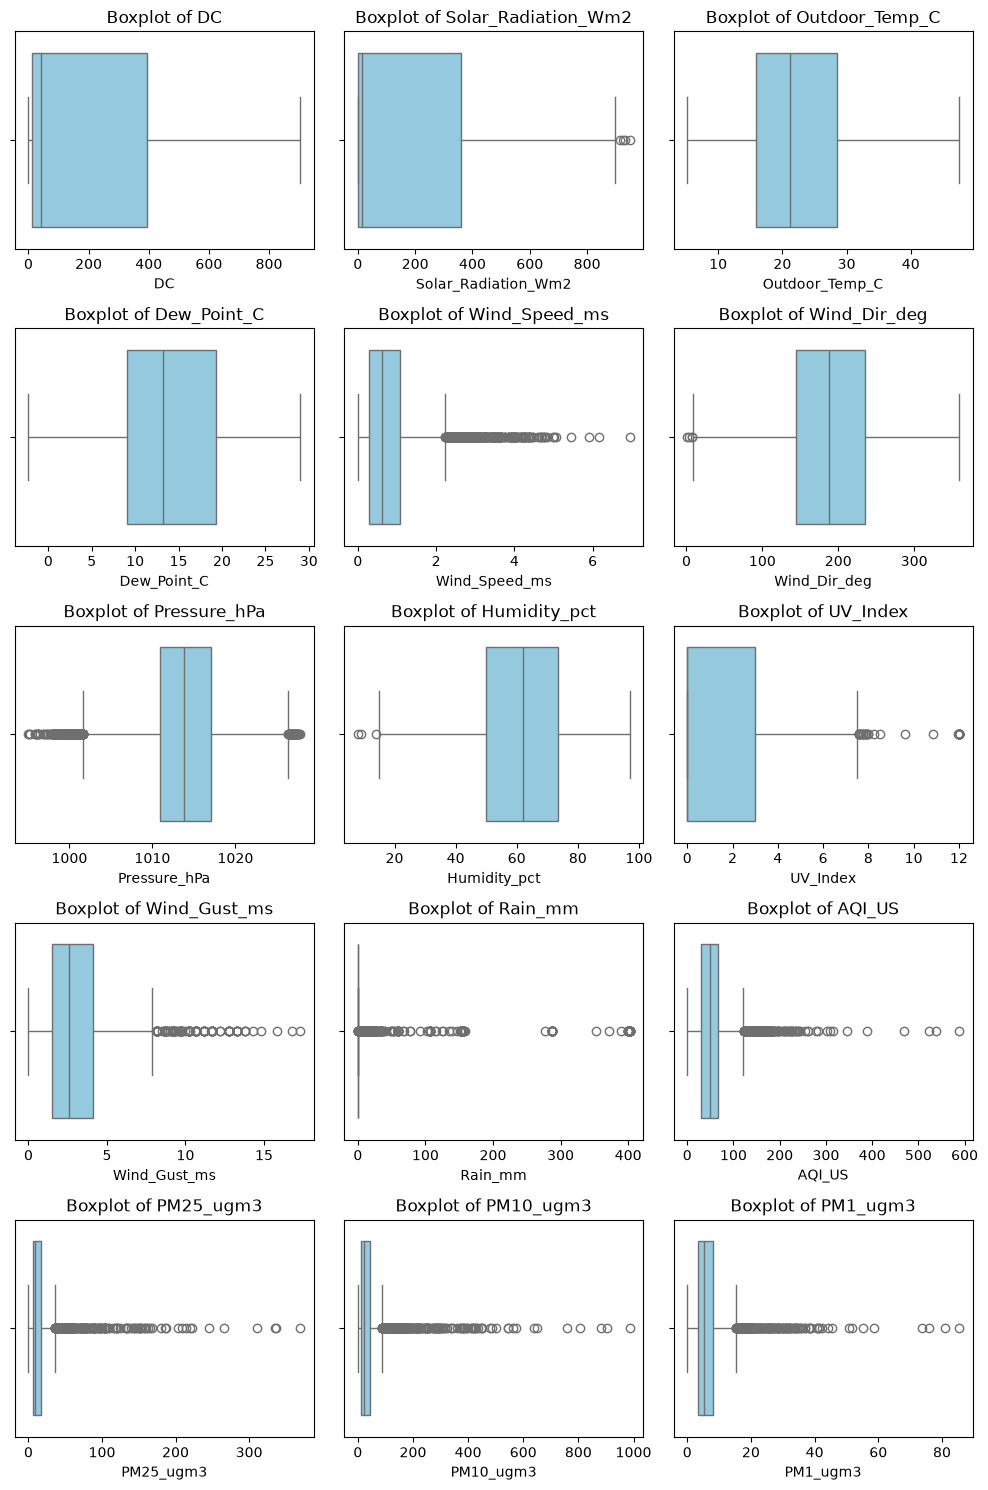

In [3]:
import math
n_cols = 3
n_features = len(df.columns)
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, n_rows * 3))
axes = axes.flatten()

for i, column in enumerate(df.columns):
    sns.boxplot(x=df[column], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot of {column}')
    axes[i].set_xlabel(column)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
filename = "Boxplot.png"
plt.savefig(f'../figures/{filename}', dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()


### Histograms and KDE

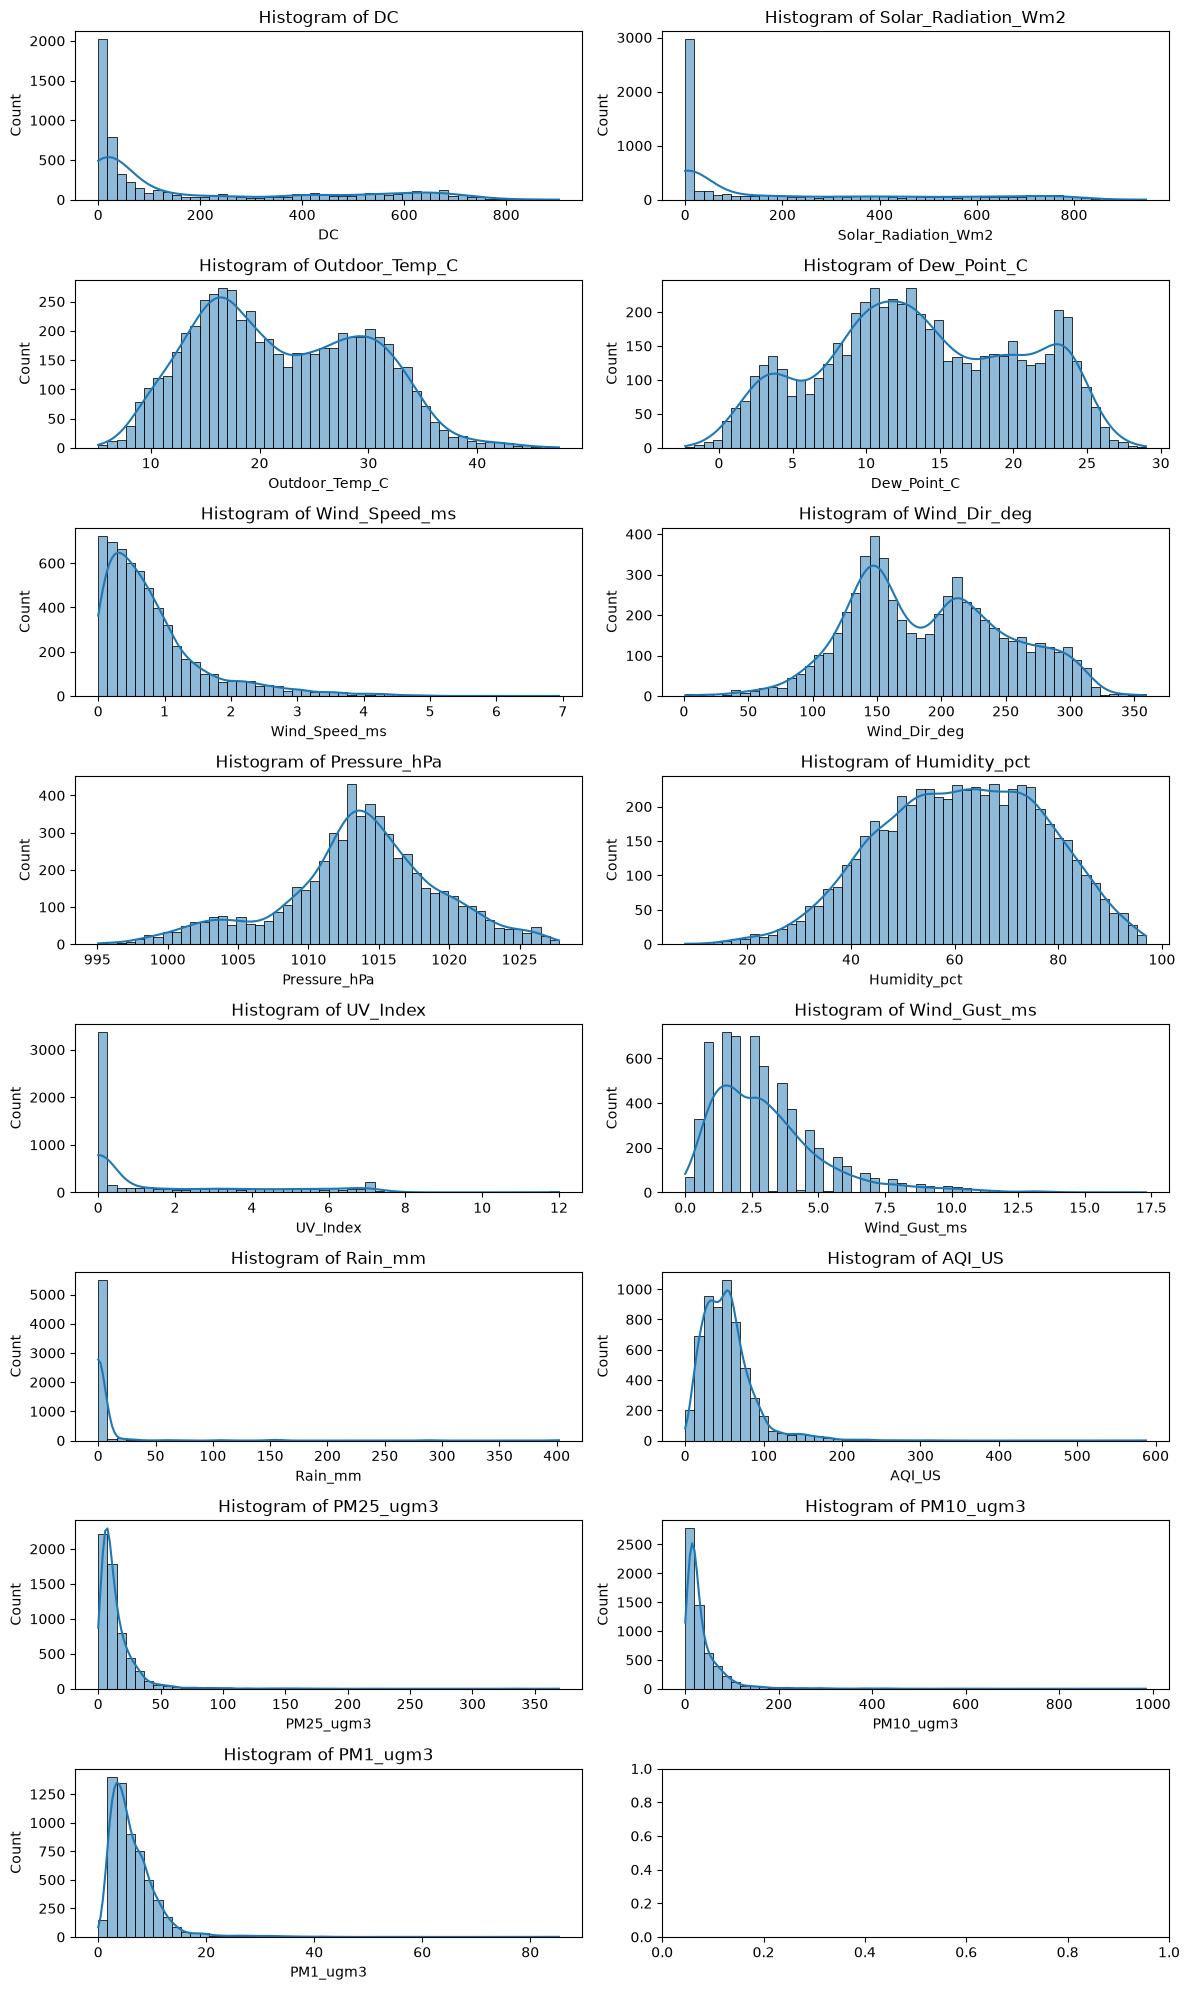

In [4]:
columns = df.columns
fig, axes = plt.subplots(nrows=len(columns)//2 + len(columns) % 2, ncols=2, figsize=(12, 20))
axes = axes.flatten()
for i, col in enumerate(columns):
    sns.histplot(df[col], bins=50, kde=True, ax=axes[i])
    axes[i].set_title(f'Histogram of {col}')
plt.tight_layout()
filename = "Histograms_and_KDE.png"
plt.savefig(f'../figures/{filename}', dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()


## Correlation Matrix

<class 'pandas.DataFrame'>
DatetimeIndex: 5832 entries, 2026-01-01 00:00:00 to 2026-08-31 23:00:00
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   DC                   5832 non-null   float64
 1   Solar_Radiation_Wm2  5832 non-null   float64
 2   Outdoor_Temp_C       5832 non-null   float64
 3   Dew_Point_C          5832 non-null   float64
 4   Wind_Speed_ms        5832 non-null   float64
 5   Wind_Dir_deg         5832 non-null   float64
 6   Pressure_hPa         5832 non-null   float64
 7   Humidity_pct         5832 non-null   float64
 8   UV_Index             5832 non-null   float64
 9   Wind_Gust_ms         5832 non-null   float64
 10  Rain_mm              5832 non-null   float64
 11  AQI_US               5832 non-null   float64
 12  PM25_ugm3            5832 non-null   float64
 13  PM10_ugm3            5832 non-null   float64
 14  PM1_ugm3             5832 non-null   float64
dtypes: float64(15

<Figure size 1400x1200 with 0 Axes>

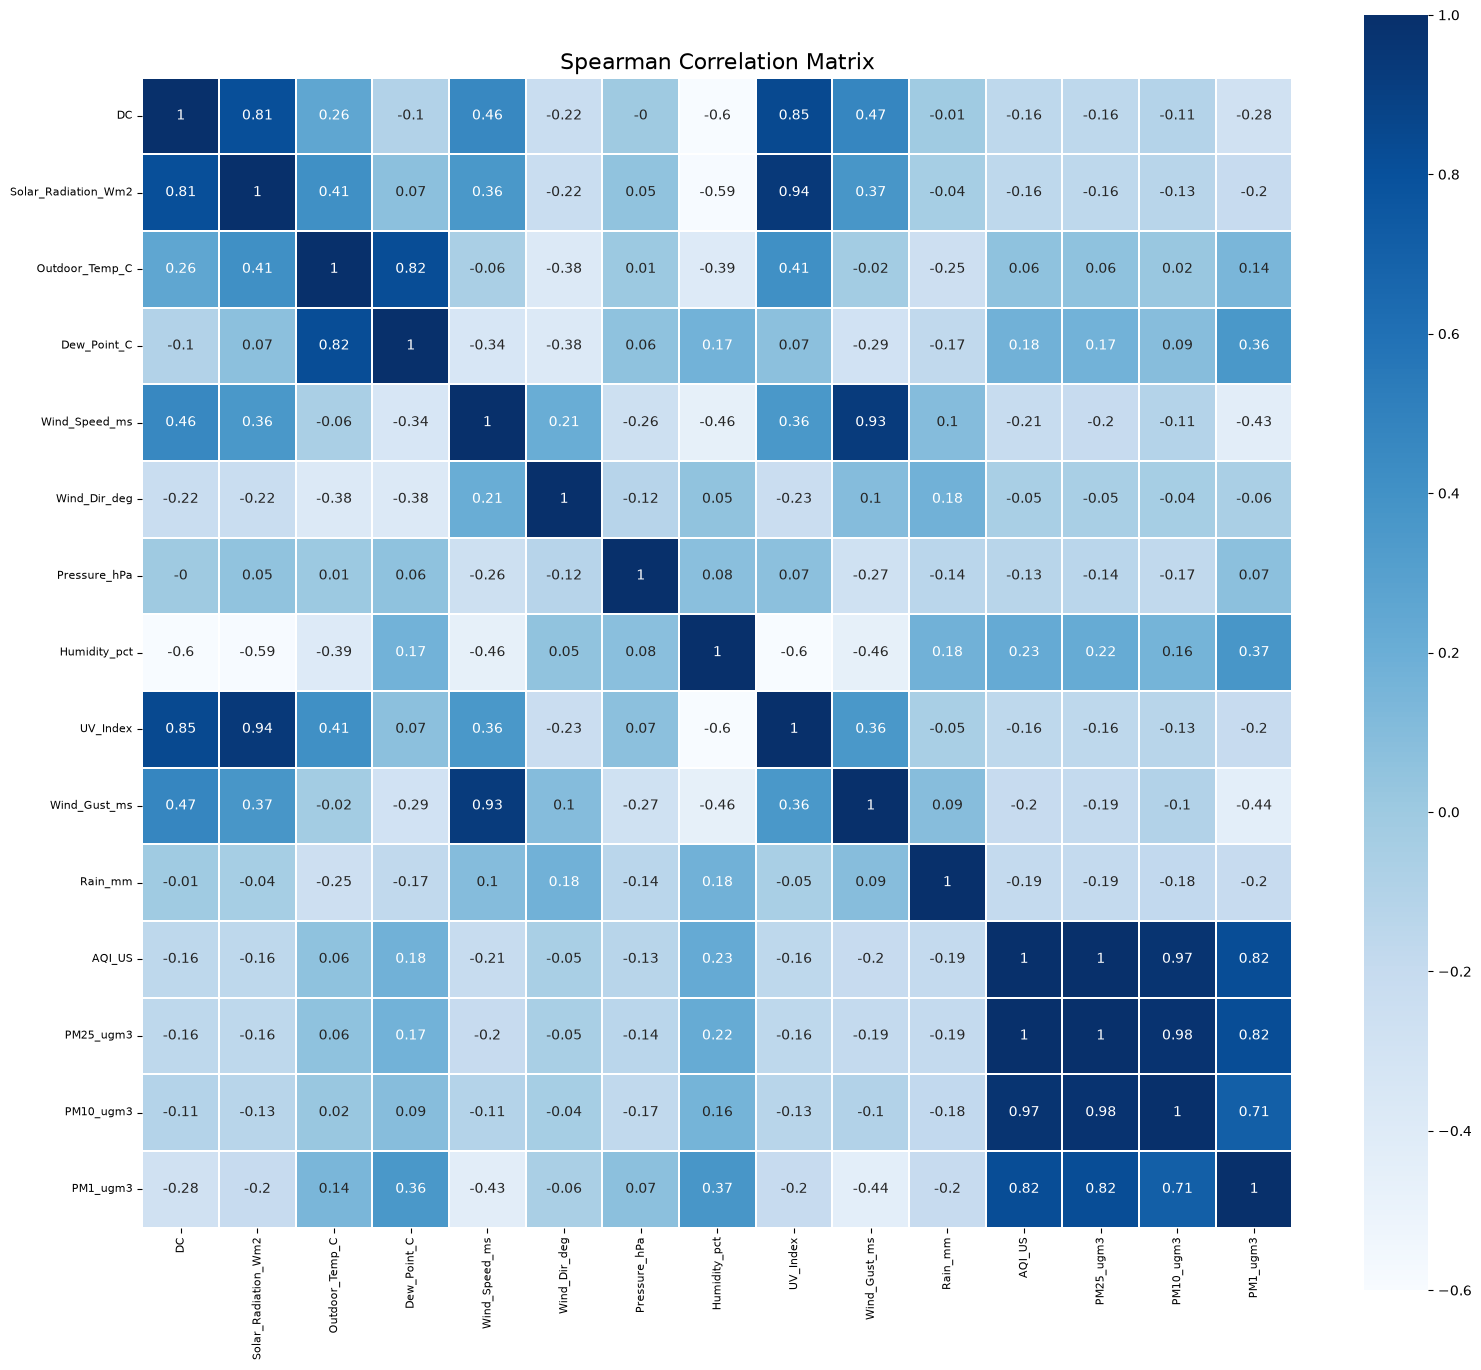

In [5]:
print(df.info())

numeric_df = df.select_dtypes(include=np.number)
corr_matrix = numeric_df.corr(method="spearman").round(2)
    
plt.figure(figsize=(14, 12))

plt.figure(figsize=(16, 14))

sns.heatmap(
    corr_matrix,
    cmap="Blues",
    annot=True,
    square=True,
    linewidths=0.2
)

plt.title('Spearman Correlation Matrix', fontsize=16)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

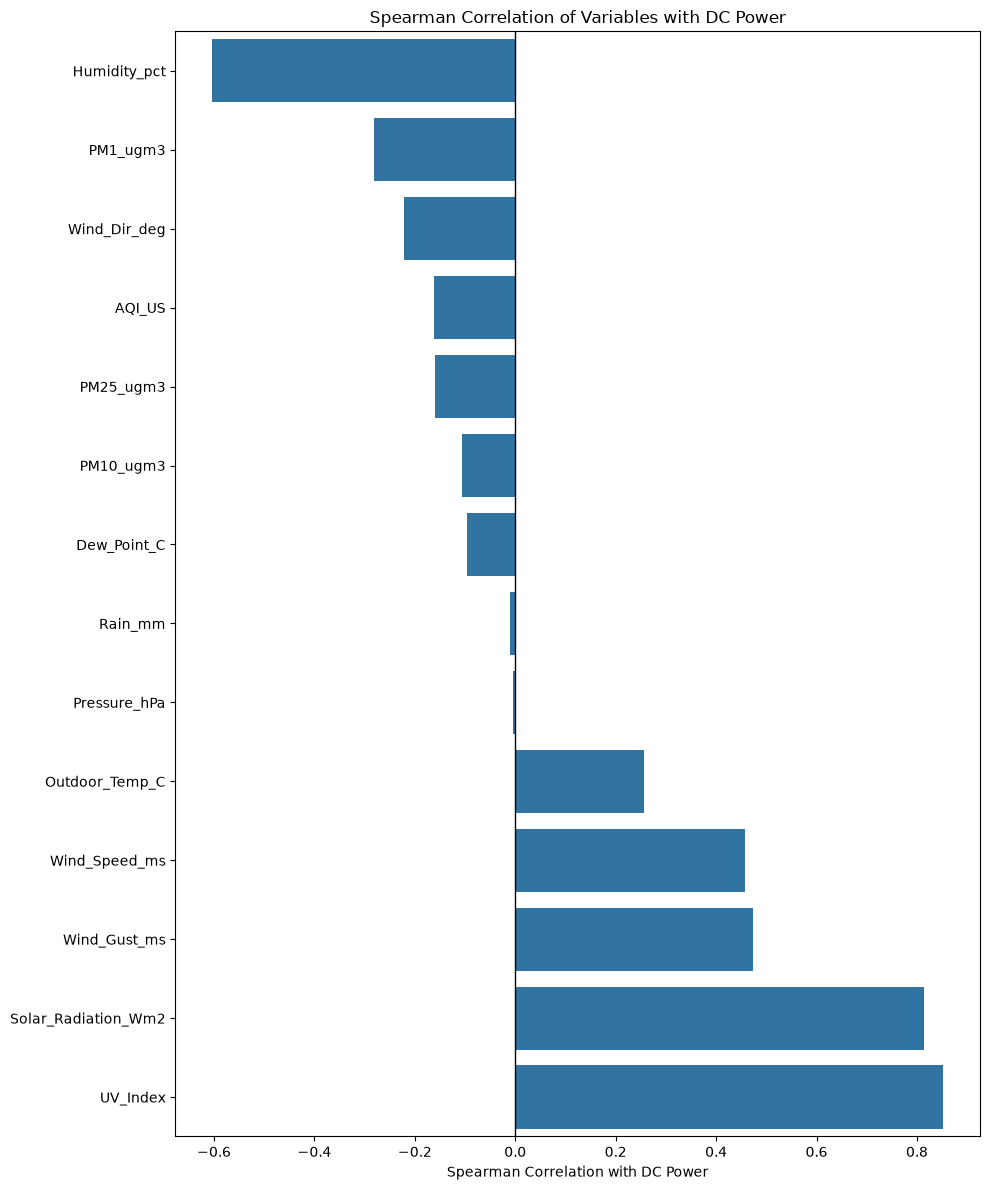

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Select numeric columns
numeric_df = df.select_dtypes(include=np.number)

# Spearman correlation with DC
target = "DC"

correlations = (
    numeric_df.corr(method="spearman")[target]
    .drop(target)
    .sort_values()
)

# Plot
plt.figure(figsize=(10, 12))

sns.barplot(
    x=correlations.values,
    y=correlations.index
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Spearman Correlation with DC Power")
plt.ylabel("")
plt.title("Spearman Correlation of Variables with DC Power")
plt.tight_layout()
plt.show()

## Pairplot

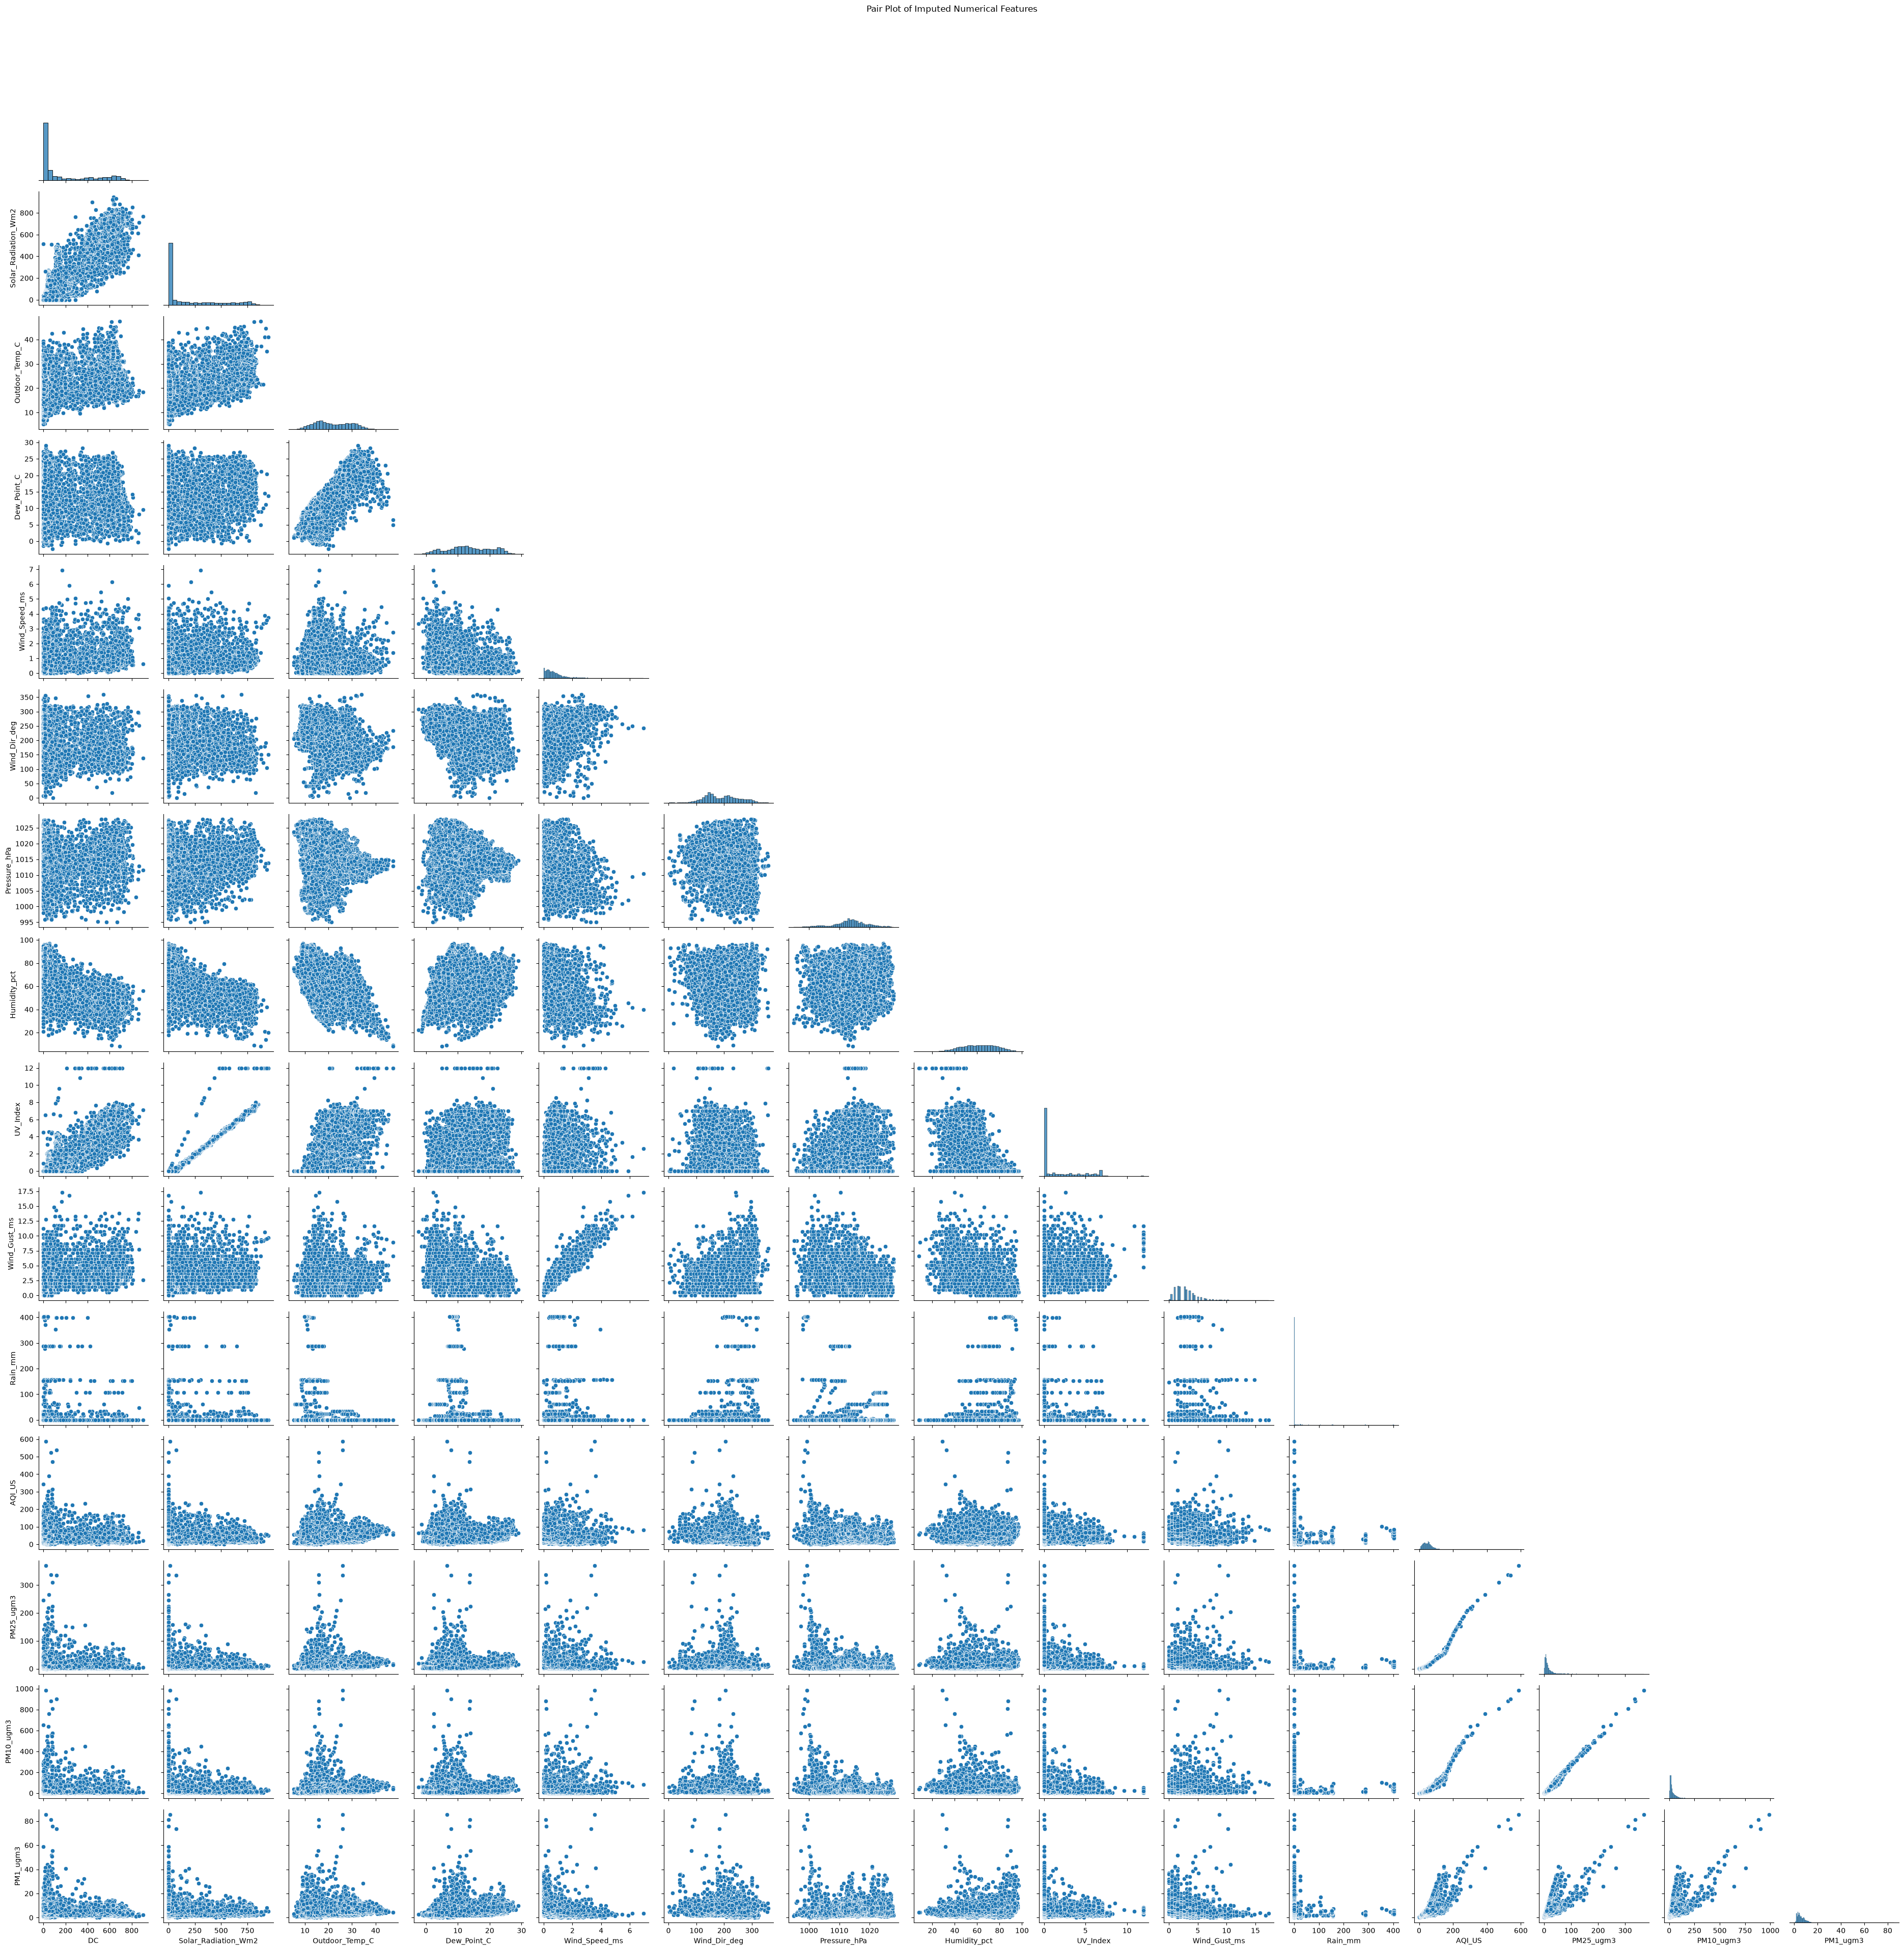

In [7]:
sns.pairplot(df, corner=True)  # corner=True avoids duplicate plots
plt.suptitle("Pair Plot of Imputed Numerical Features", y=1.02)
plt.tight_layout()
filename = "pair_plot.png"
plt.savefig(f'../figures/{filename}', dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()


## Rolling Mean (Weekly)

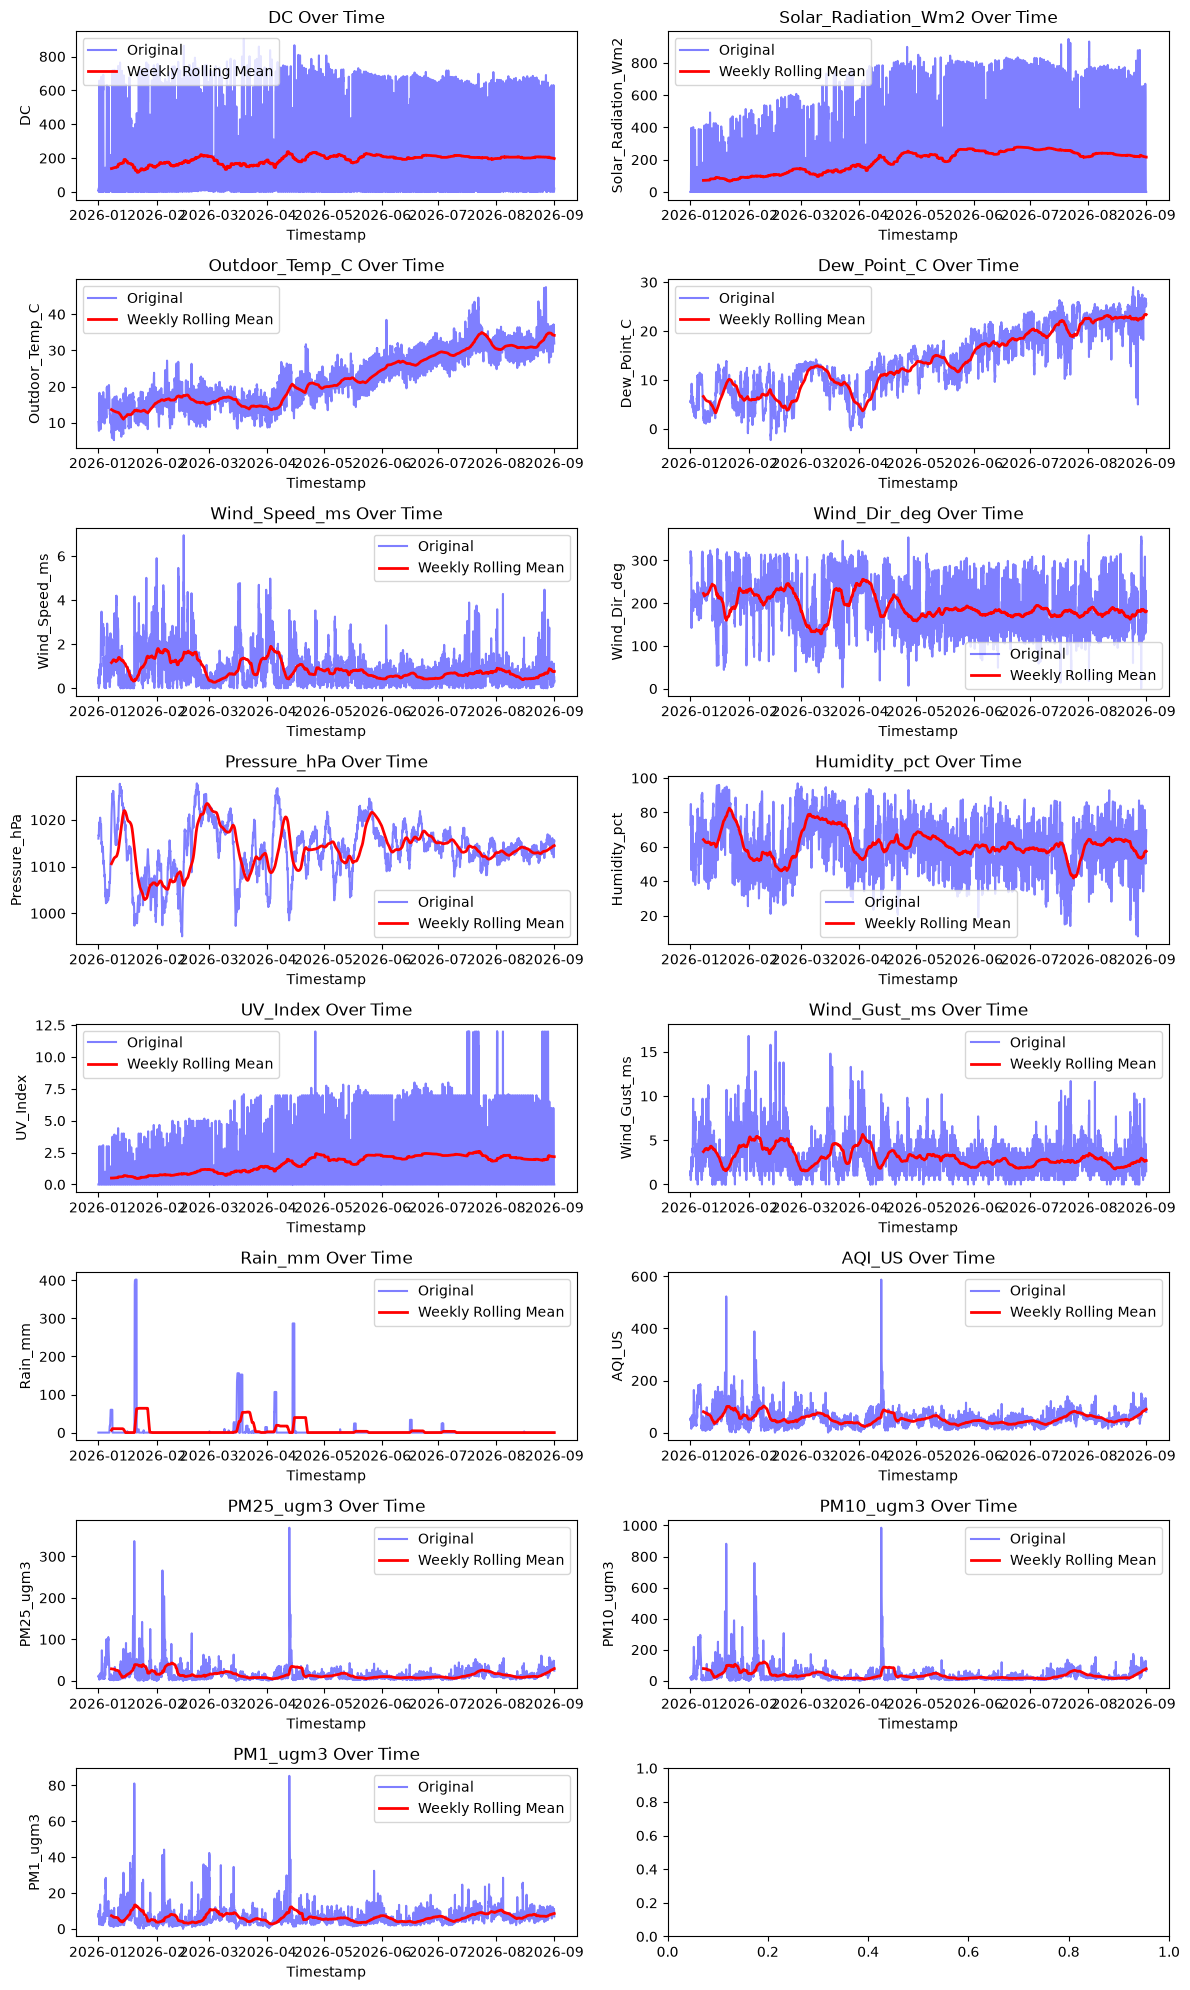

In [8]:
df_reset = df.reset_index()
rolling_window = 7 * 24  # 7 days * 24 hours

fig, axes = plt.subplots(nrows=len(columns)//2 + len(columns) % 2, ncols=2, figsize=(12, 20))
axes = axes.flatten()

for i, col in enumerate(columns):
    axes[i].plot(df_reset['Timestamp'], df_reset[col], alpha=0.5, label='Original', color='blue')
    rolling_mean = df_reset[col].rolling(window=rolling_window).mean()
    axes[i].plot(df_reset['Timestamp'], rolling_mean, label='Weekly Rolling Mean', color='red', linewidth=2)
    axes[i].set_title(f'{col} Over Time')
    axes[i].set_xlabel('Timestamp')
    axes[i].set_ylabel(col)
    axes[i].legend()

plt.tight_layout()
filename = "rolling_mean.png"
plt.savefig(f'../figures/{filename}', dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()


## Time Series Decomposition

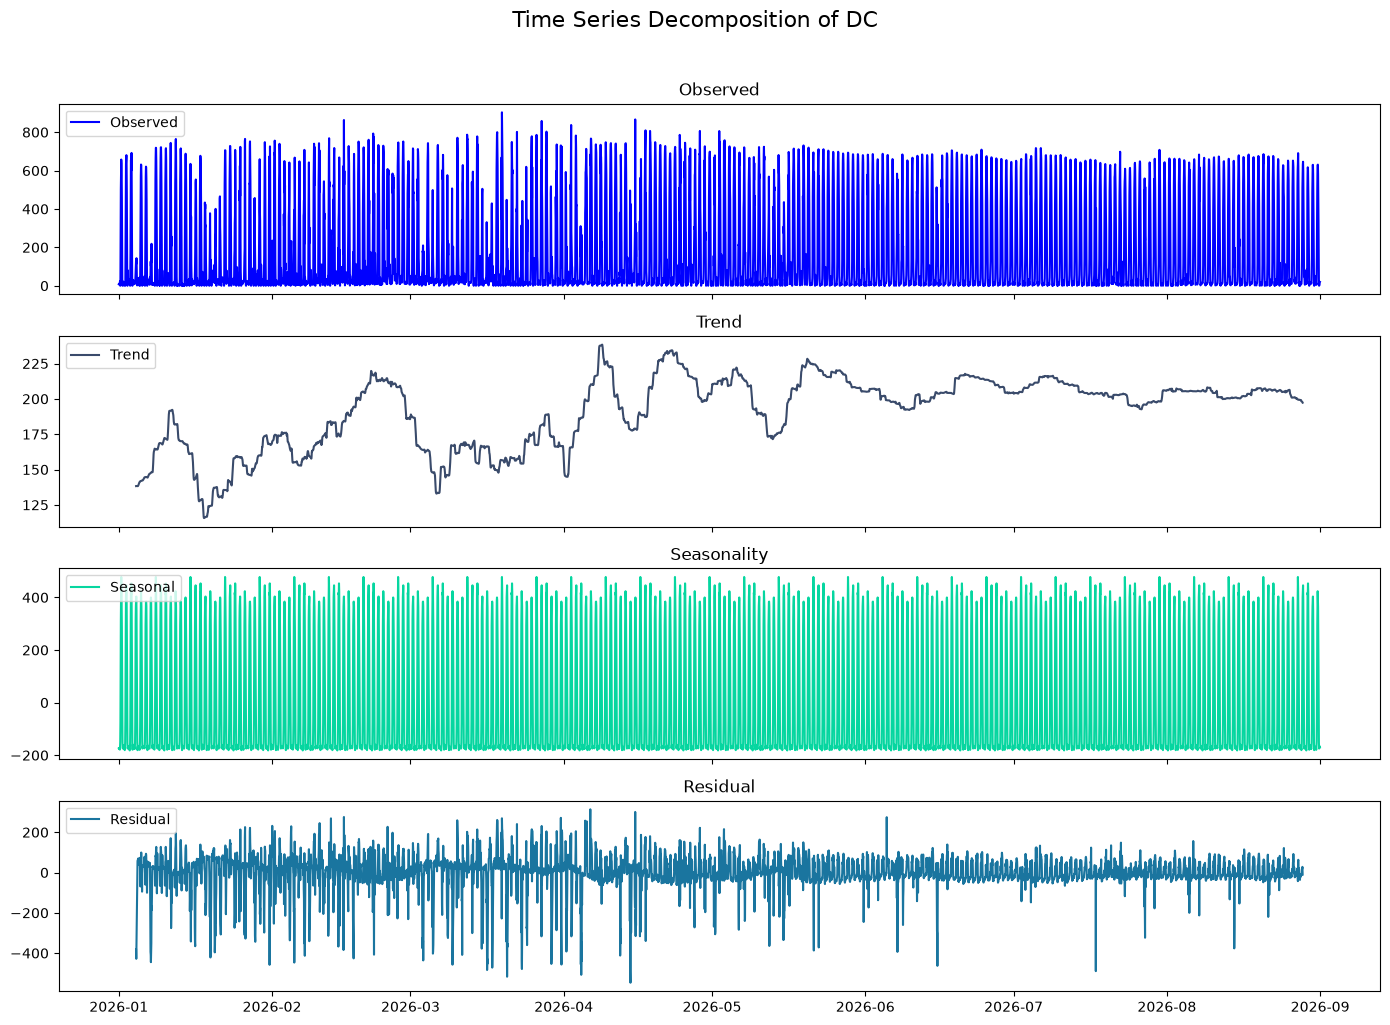

In [9]:
dc_series = df['DC'].dropna()

decomposition = seasonal_decompose(dc_series, model='additive', period=168)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(decomposition.observed, label='Observed', color='blue')
axes[0].legend(loc='upper left')
axes[0].set_title("Observed")

axes[1].plot(decomposition.trend, label='Trend', color='#3A4B6B')
axes[1].legend(loc='upper left')
axes[1].set_title("Trend")

axes[2].plot(decomposition.seasonal, label='Seasonal', color='#06d6a0')
axes[2].legend(loc='upper left')
axes[2].set_title("Seasonality")

axes[3].plot(decomposition.resid, label='Residual', color='#1a759f')
axes[3].legend(loc='upper left')
axes[3].set_title("Residual")

plt.suptitle("Time Series Decomposition of DC", y=1.02, fontsize=16)
plt.tight_layout()
filename = "seasonal_decomposition.png"
plt.savefig(f'../figures/{filename}', dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()


## Stationarity Check

### Visual Method (Rolling Mean / Std)

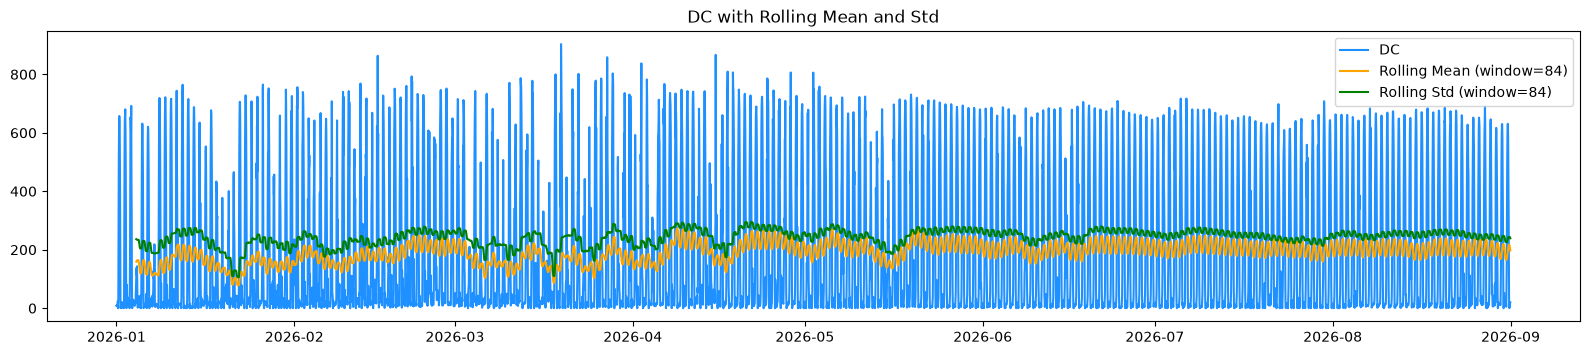

In [10]:
dc_series = df['DC']

rolling_mean = dc_series.rolling(window=84).mean()
rolling_std = dc_series.rolling(window=84).std()

plt.figure(figsize=(16, 10))
plt.subplot(3, 1, 1)
plt.plot(dc_series, label='DC', color='dodgerblue')
plt.plot(rolling_mean, label='Rolling Mean (window=84)', color='orange')
plt.plot(rolling_std, label='Rolling Std (window=84)', color='green')
plt.legend()
plt.title('DC with Rolling Mean and Std')

plt.tight_layout()
filename = "rolling_mean_and_std.png"
plt.savefig(f'../figures/{filename}', dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()


### Statistical Test (Augmented Dickey-Fuller)

In [11]:
dc_series = df['DC']

adf_result = adfuller(dc_series)

print("\n--- Augmented Dickey-Fuller Test ---")
print(f"ADF Statistic      : {adf_result[0]}")
print(f"p-value            : {adf_result[1]}")
print(f"# Lags Used        : {adf_result[2]}")
print(f"# Observations Used: {adf_result[3]}")
print("Critical Values    :")
for key, value in adf_result[4].items():
    print(f" {key} : {value}")



--- Augmented Dickey-Fuller Test ---
ADF Statistic      : -9.974495557990933
p-value            : 2.1958355286244454e-17
# Lags Used        : 26
# Observations Used: 5805
Critical Values    :
 1% : -3.431476992937525
 5% : -2.8620380242135113
 10% : -2.5670350962778974


## Final Time Series Plot

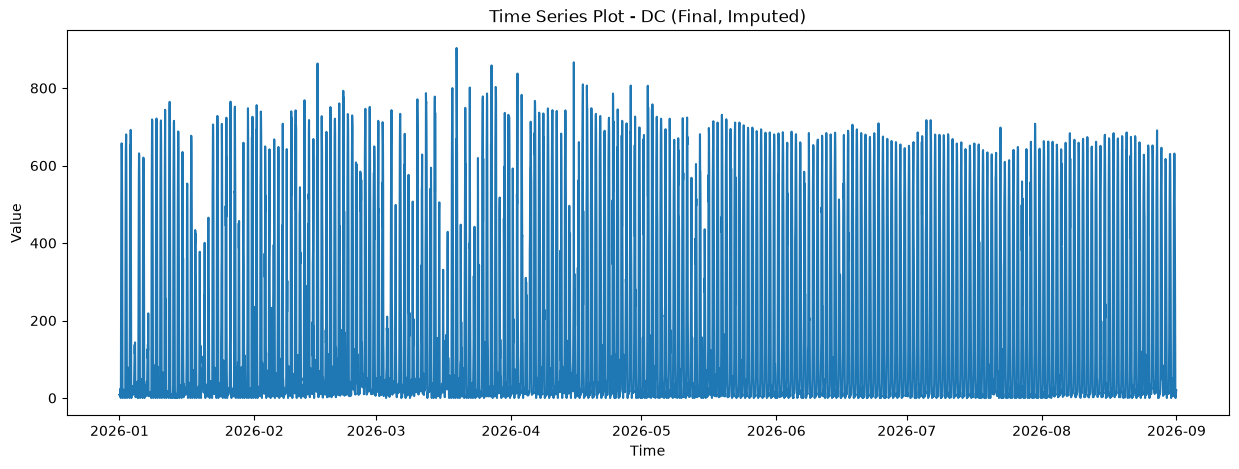

In [12]:
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['DC'])
plt.title('Time Series Plot - DC (Final, Imputed)')
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()

### ACF and PACF

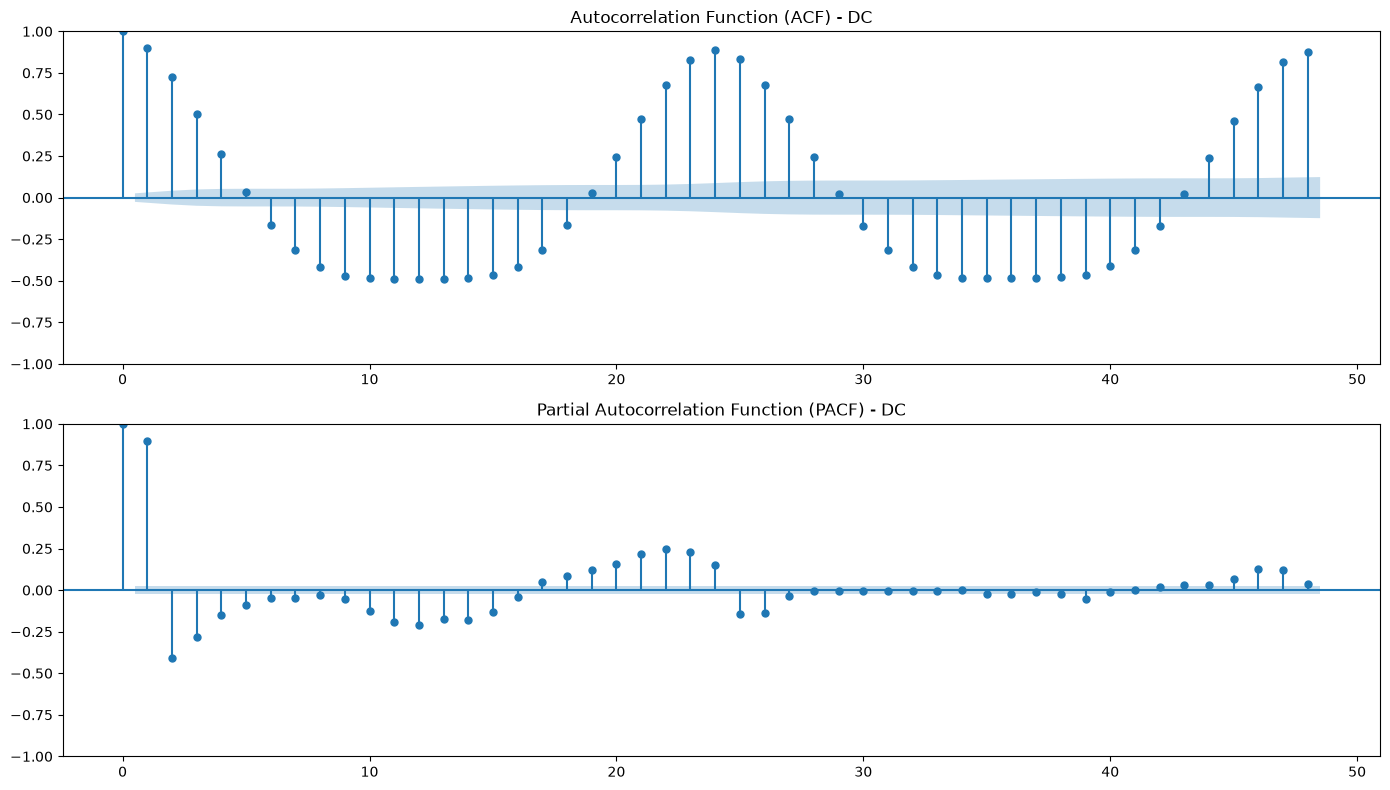

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

dc_series = df['DC'].dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(dc_series, lags=48, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF) - DC')

plot_pacf(dc_series, lags=48, method='ywm', ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF) - DC')

plt.tight_layout()
filename = "acf_pacf.png"
plt.savefig(f'../figures/{filename}', dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()